In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

(60000, 28, 28)


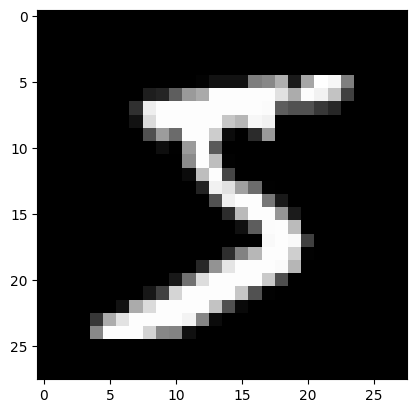

In [2]:
(Xtrain, Ytrain), (Xtest, Ytest) = tf.keras.datasets.mnist.load_data()
plt.imshow(Xtrain[0], cmap='gray')

plt.show

print(Xtrain.shape)

In [3]:
def one_hot(Y, nclass=10):
    Y_ = np.zeros((Y.shape[0], nclass))
    
    for i, y in enumerate(Y):
        Y_[i, Y[i]] = 1
        
    return Y_

In [4]:
Ytrain = one_hot(Ytrain)
Ytest = one_hot(Ytest)

Xtrain = Xtrain.reshape(-1, 28*28)
Xtest = Xtest.reshape(-1, 28*28)

d_in = (Xtrain.shape[1],)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(200, input_shape=d_in, 
                                activation='relu'))
model.add(tf.keras.layers.Dense(200,
                                activation='relu'))
model.add(tf.keras.layers.Dense(10,
                                activation='softmax'))
model.compile(loss=tf.keras.losses.MeanSquaredError(),
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.001))

model.fit(
    Xtrain / 255., 
    Ytrain,
    epochs=50,
    validation_data=(Xtest, Ytest)
        )

Epoch 1/50
1875/1875 [==============================] - 7s 3ms/step - loss: 0.0896 - val_loss: 0.1696
Epoch 2/50
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0890 - val_loss: 0.1634
Epoch 3/50
1875/1875 [==============================] - 3s 2ms/step - loss: 0.0885 - val_loss: 0.1572
Epoch 4/50
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0879 - val_loss: 0.1532
Epoch 5/50
1875/1875 [==============================] - 17s 9ms/step - loss: 0.0873 - val_loss: 0.1500
Epoch 6/50
1875/1875 [==============================] - 18s 10ms/step - loss: 0.0867 - val_loss: 0.1464
Epoch 7/50
1875/1875 [==============================] - 18s 10ms/step - loss: 0.0860 - val_loss: 0.1433
Epoch 8/50
1875/1875 [==============================] - 14s 7ms/step - loss: 0.0853 - val_loss: 0.1404
Epoch 9/50
1875/1875 [==============================] - 18s 10ms/step - loss: 0.0846 - val_loss: 0.1367
Epoch 10/50
1875/1875 [==============================] - 17s 9ms/step - l

In [ ]:
Z = model.predict(Xtest / 255.)
print(np.sum(Z.argmax(axis=1) == Ytest.argmax(axis=1)) / len(Ytest))

313/313 [==============================] - 1s 4ms/step
0.8292
